# Netflix Stock Price Prediction 

## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [8]:
df = pd.read_csv("NFLX.csv")


## 3. Understand the Dataset

In [9]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [10]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200
1008,2022-02-04,407.309998,412.769989,396.640015,410.170013,410.170013,7782400


In [12]:
df.shape

(1009, 7)

In [13]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   str    
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 65.2 KB


In [15]:
df.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [16]:
df.nunique()

Date         1009
Open          976
High          983
Low           989
Close         988
Adj Close     988
Volume       1005
dtype: int64

## 4. Check Data Quality

In [17]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

## 5. Clean the Data

In [19]:
df = df.dropna()


## 6. Statistical Analysis

In [20]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


In [21]:
df.describe(include='all')

,Date,Open,High,Low,Close,Adj Close,Volume
count,1009,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
unique,1009,NaN,NaN,NaN,NaN,NaN,NaN
top,2018-02-05,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,NaN,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,NaN,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,NaN,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,NaN,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,NaN,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06


## 7. Quick Visual Analysis

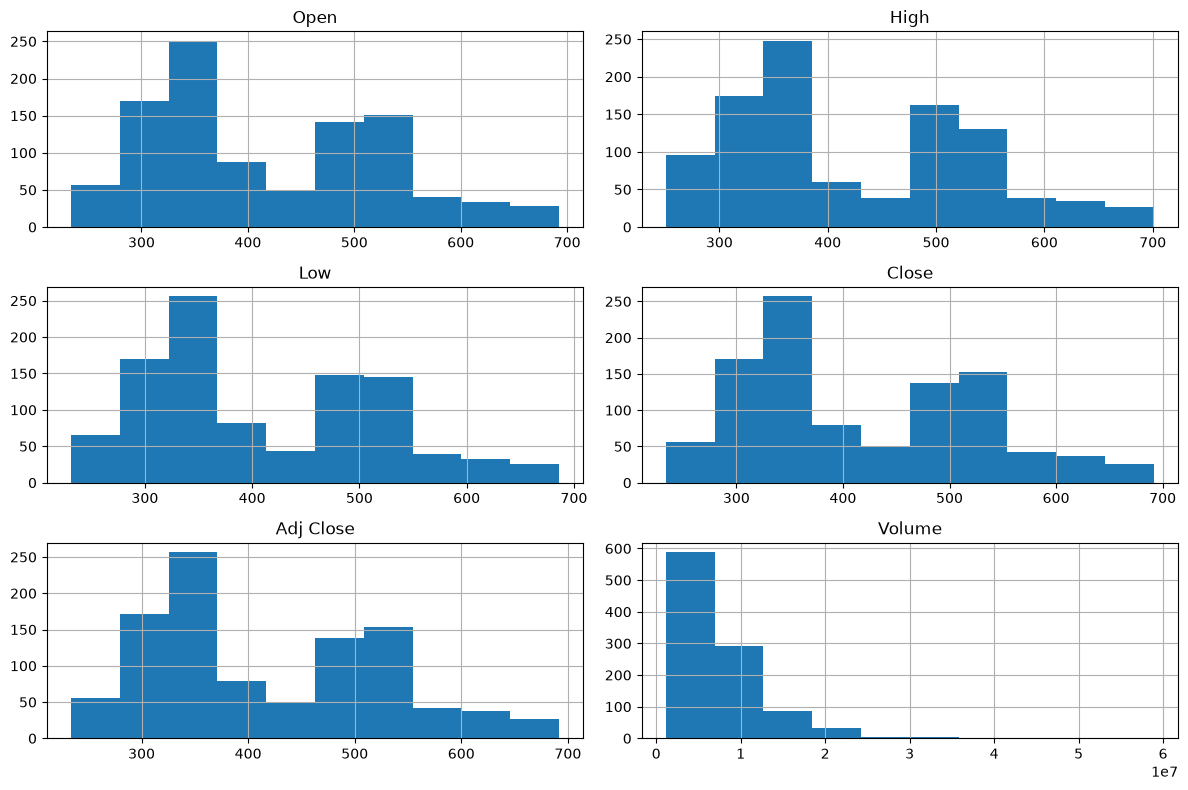

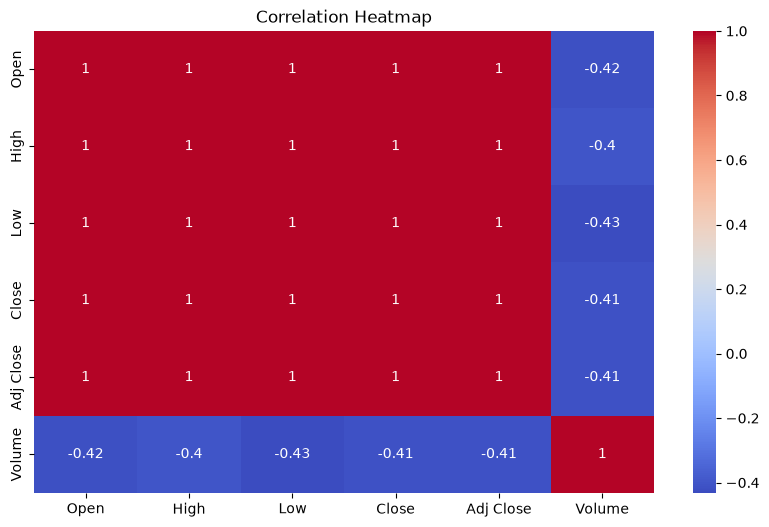

In [22]:
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:
    df[numeric_cols].hist(figsize=(12, 8))
    plt.tight_layout()
    plt.show()

# Correlation heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

## 8. Convert Data

In [23]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


## 9. Plot Netflix closing price

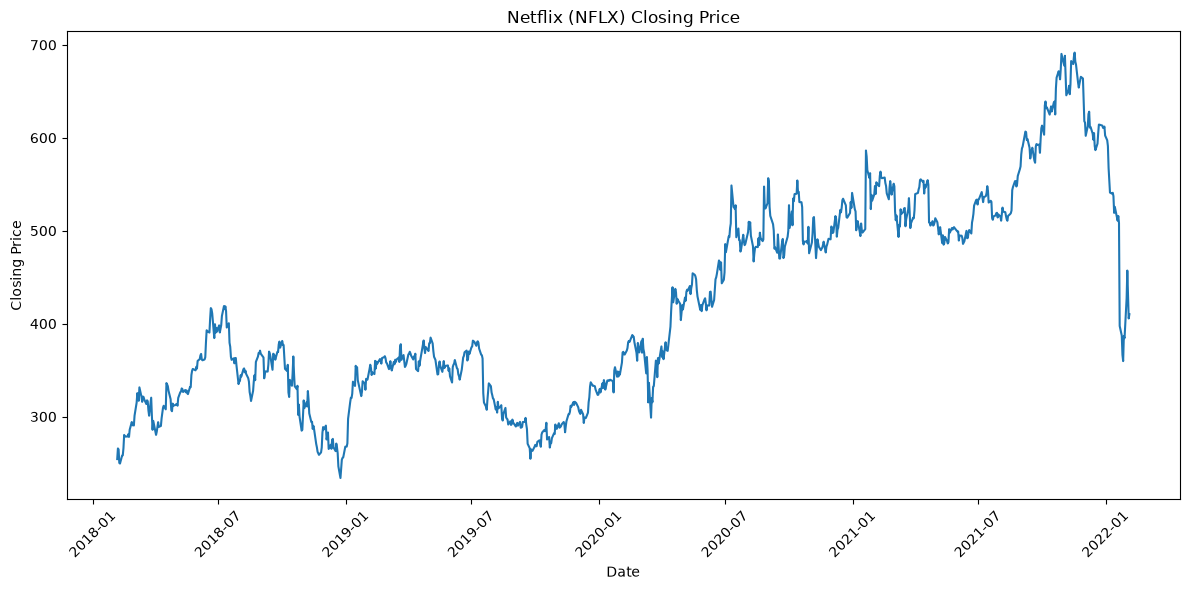

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Close'])

plt.title('Netflix (NFLX) Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 10. Check the prediction target

In [25]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
         Open        High         Low    Volume
0  262.000000  267.899994  250.029999  11896100
1  247.699997  266.700012  245.000000  12595800
2  266.579987  272.450012  264.329987   8981500
3  267.079987  267.619995  250.000000   9306700
4  253.850006  255.800003  236.110001  16906900

Target:
0    254.259995
1    265.720001
2    264.559998
3    250.100006
4    249.470001
Name: Close, dtype: float64


## 11. Training and Testing

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (807, 4)
Testing data: (202, 4)


## 12. Train Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 13. Make predictions 

In [28]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[509.47511894 509.42288906 506.36327304 506.52577944 509.8220461
 505.36956258 505.1233519  507.97303809 512.06718757 506.22787724]


## 14. Evaluate the model

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.541851212453506
RMSE: 6.127072176898066
R² Score: 0.9924207881459658


## 15. Visualize Actual vs Predicted

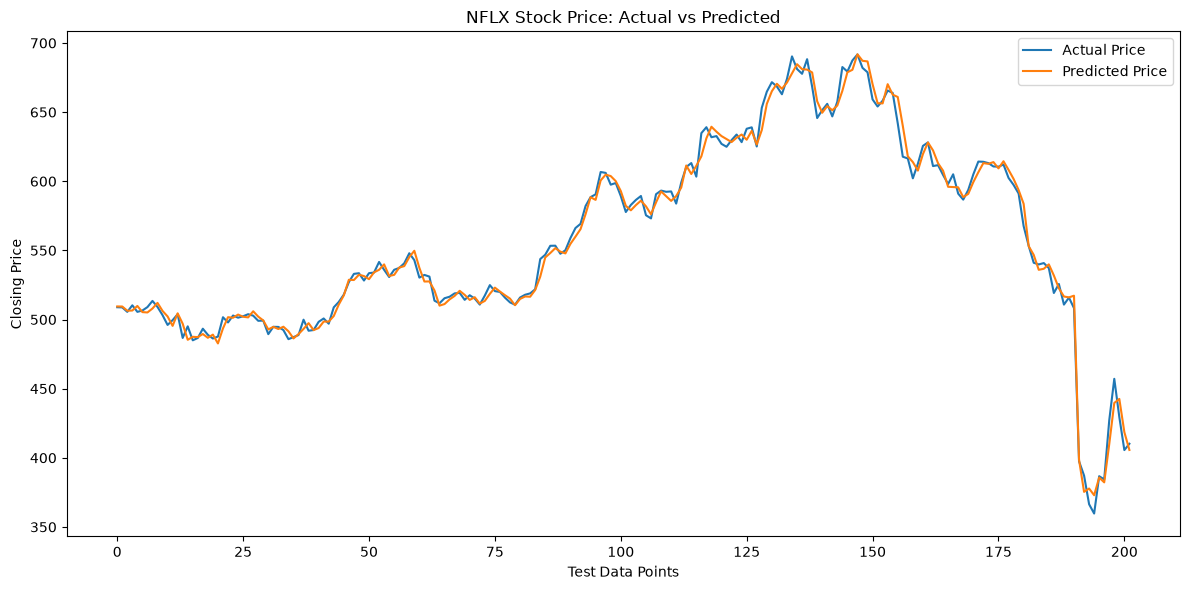

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.title('NFLX Stock Price: Actual vs Predicted')
plt.xlabel('Test Data Points')
plt.ylabel('Closing Price')
plt.legend()

plt.tight_layout()
plt.show()

## 16. Compare Actual vs Predicted

In [32]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,508.899994,509.475119
1,508.779999,509.422889
2,505.549988,506.363273
3,510.299988,506.525779
4,505.549988,509.822046
5,506.519989,505.369563
6,509.000000,505.123352
7,513.469971,507.973038
8,509.109985,512.067188
9,503.179993,506.227877


## 17.Calculate prediction error

In [33]:
comparison['Error'] = comparison['Actual Price'] - comparison['Predicted Price']

comparison.head(10)

,Actual Price,Predicted Price,Error
0,508.899994,509.475119,-0.575125
1,508.779999,509.422889,-0.642890
2,505.549988,506.363273,-0.813285
3,510.299988,506.525779,3.774209
4,505.549988,509.822046,-4.272058
5,506.519989,505.369563,1.150426
6,509.000000,505.123352,3.876648
7,513.469971,507.973038,5.496933
8,509.109985,512.067188,-2.957203
9,503.179993,506.227877,-3.047884


## 18. Plot the prediction error

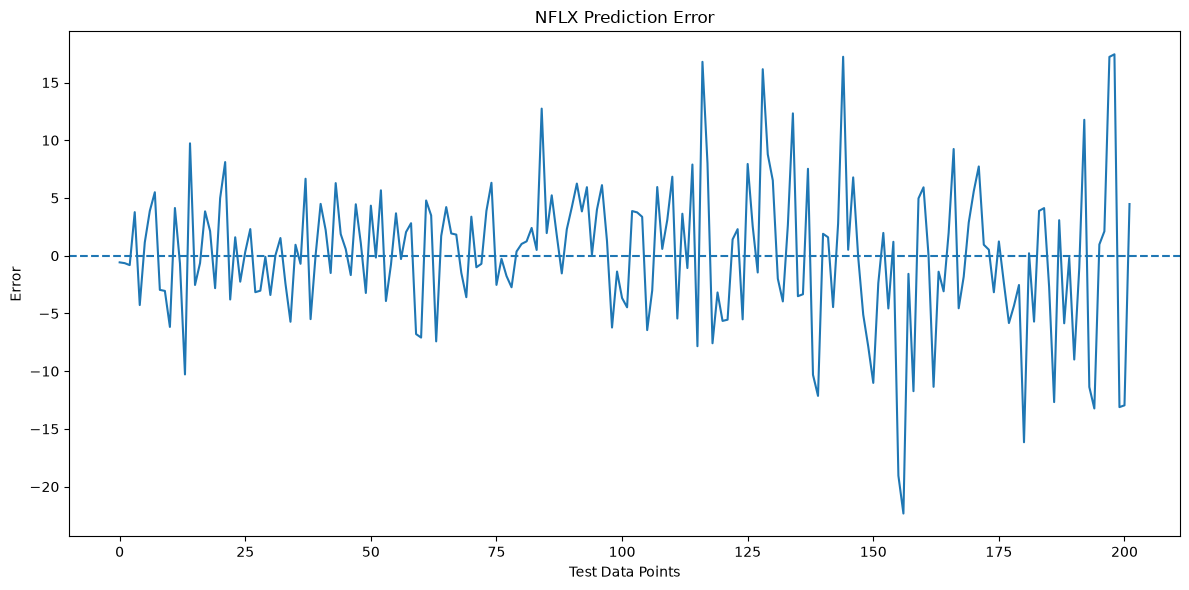

In [34]:
plt.figure(figsize=(12, 6))

plt.plot(comparison['Error'])

plt.axhline(y=0, linestyle='--')

plt.title('NFLX Prediction Error')
plt.xlabel('Test Data Points')
plt.ylabel('Error')

plt.tight_layout()
plt.show()

## 19. Try Random Forest Regression

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 20. Evaluate Random Forest

In [36]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 25.857168878861714
RMSE: 42.50341597930544
R² Score: 0.6352748387928743


## 21. Compare both models

In [37]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R² Score': [r2, rf_r2]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,4.541851,6.127072,0.992421
1,Random Forest,25.857169,42.503416,0.635275


## 22. Feature Importance

In [38]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,Low,0.583176
1,High,0.414764
0,Open,0.001555
3,Volume,0.000505


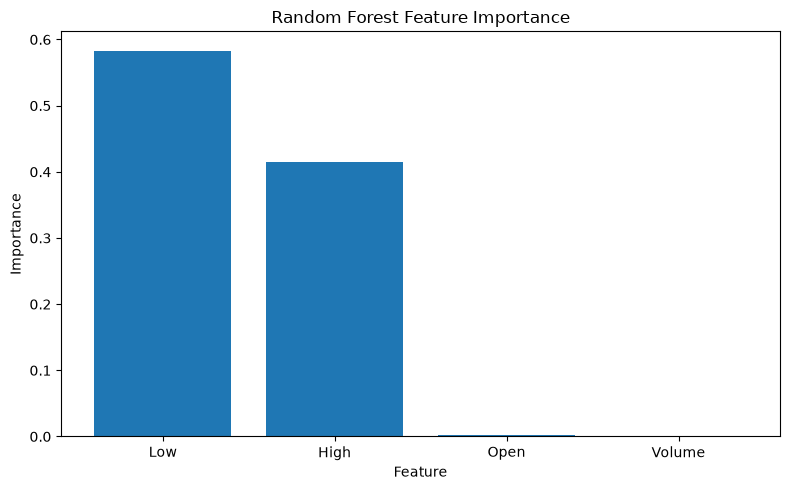

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.tight_layout()
plt.show()

## 23. Add a previous-day closing price 

In [40]:
df['Previous_Close'] = df['Close'].shift(1)

df[['Date', 'Close', 'Previous_Close']].head()

,Date,Close,Previous_Close
0,2018-02-05,254.259995,NaN
1,2018-02-06,265.720001,254.259995
2,2018-02-07,264.559998,265.720001
3,2018-02-08,250.100006,264.559998
4,2018-02-09,249.470001,250.100006


## 24. Removing the missing row

In [41]:
df = df.dropna()
print("New shape:", df.shape)

New shape: (1008, 8)


## 25. Create new features and target

In [42]:
X = df[['Open', 'High', 'Low', 'Volume', 'Previous_Close']]
y = df['Close']

print("Features:", X.columns.tolist())
print("Target: Close")

Features: ['Open', 'High', 'Low', 'Volume', 'Previous_Close']
Target: Close


## 26. New train/test split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (806, 5)
Testing data: (202, 5)


## 27. Train Linear Regression again

In [44]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Improved Linear Regression trained successfully!")

Improved Linear Regression trained successfully!


## 28. Evaluate the improved model

In [45]:
mae_new = mean_absolute_error(y_test, y_pred)
rmse_new = np.sqrt(mean_squared_error(y_test, y_pred))
r2_new = r2_score(y_test, y_pred)

print("Improved Linear Regression")
print("MAE:", mae_new)
print("RMSE:", rmse_new)
print("R² Score:", r2_new)

Improved Linear Regression
MAE: 3.830361043349137
RMSE: 5.796653768437093
R² Score: 0.9932162040578548


## 29. Create a next-day target 

In [47]:
df['Next_Close'] = df['Close'].shift(-1)

df[['Date', 'Close', 'Next_Close']].head()

,Date,Close,Next_Close
1,2018-02-06,265.720001,264.559998
2,2018-02-07,264.559998,250.100006
3,2018-02-08,250.100006,249.470001
4,2018-02-09,249.470001,257.950012
5,2018-02-12,257.950012,258.269989


## 30. Remove the final NaN

In [48]:
df = df.dropna()

print("Shape:", df.shape)

Shape: (1007, 9)


## 31. Create the proper prediction features

In [49]:
X = df[['Open', 'High', 'Low', 'Volume', 'Close']]
y = df['Next_Close']

print("Features:", X.columns.tolist())
print("Target: Next_Close")

Features: ['Open', 'High', 'Low', 'Volume', 'Close']
Target: Next_Close


## 32. Time-series train/test split 

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (805, 5)
Testing data: (202, 5)


## 33. Train and evaluation

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_next = LinearRegression()

model_next.fit(X_train, y_train)

y_pred_next = model_next.predict(X_test)

mae_next = mean_absolute_error(y_test, y_pred_next)
rmse_next = np.sqrt(mean_squared_error(y_test, y_pred_next))
r2_next = r2_score(y_test, y_pred_next)

print("Next-Day Prediction Results")
print("MAE:", mae_next)
print("RMSE:", rmse_next)
print("R² Score:", r2_next)

Next-Day Prediction Results
MAE: 7.9246295279422405
RMSE: 13.084681072698665
R² Score: 0.9654343811236609


## 34. Actual vs Predicted

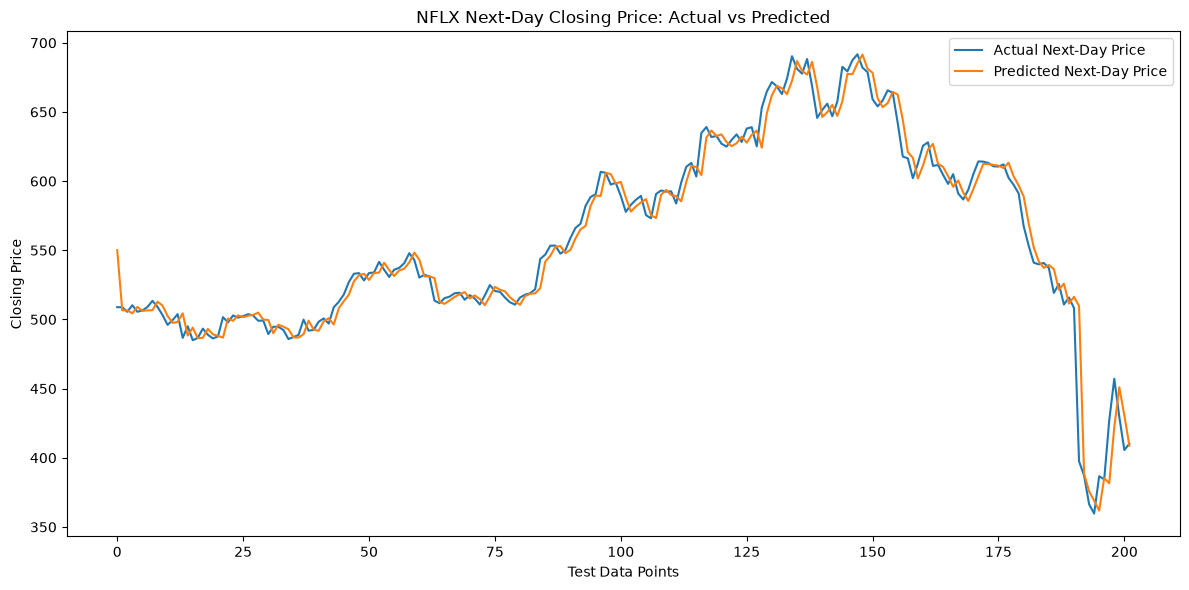

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label='Actual Next-Day Price')
plt.plot(y_pred_next, label='Predicted Next-Day Price')

plt.title('NFLX Next-Day Closing Price: Actual vs Predicted')
plt.xlabel('Test Data Points')
plt.ylabel('Closing Price')
plt.legend()

plt.tight_layout()
plt.show()

## 35. Find model comparison

In [53]:
results_final = pd.DataFrame({
    'Model': [
        'Linear Regression - Same Day',
        'Random Forest - Same Day',
        'Improved Linear Regression - Same Day',
        'Linear Regression - Next Day'
    ],
    'MAE': [
        mae,
        rf_mae,
        mae_new,
        mae_next
    ],
    'RMSE': [
        rmse,
        rf_rmse,
        rmse_new,
        rmse_next
    ],
    'R² Score': [
        r2,
        rf_r2,
        r2_new,
        r2_next
    ]
})

results_final

,Model,MAE,RMSE,R² Score
0,Linear Regression - Same Day,4.541851,6.127072,0.992421
1,Random Forest - Same Day,25.857169,42.503416,0.635275
2,Improved Linear Regression - Same Day,3.830361,5.796654,0.993216
3,Linear Regression - Next Day,7.924630,13.084681,0.965434


## 36. Prediction error Analysis

In [56]:
from sklearn.linear_model import LinearRegression
import numpy as np

model_improved = LinearRegression()
model_improved.fit(X_train, y_train)

y_pred_best = model_improved.predict(X_test)

errors = y_test - y_pred_best

print("Prediction Error Analysis")
print("--------------------------------")
print(f"Mean Error: {errors.mean():.4f}")
print(f"Minimum Error: {errors.min():.4f}")
print(f"Maximum Error: {errors.max():.4f}")
print(f"Mean Absolute Error: {np.abs(errors).mean():.4f}")

Prediction Error Analysis
--------------------------------
Mean Error: -0.1413
Minimum Error: -112.2870
Maximum Error: 45.6134
Mean Absolute Error: 7.9246


In [57]:
print("Improved Same-Day Model")
print("----------------------")
print(f"MAE: {mean_absolute_error(y_test, model_improved.predict(X_test)):.6f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, model_improved.predict(X_test))):.6f}")
print(f"R² Score: {r2_score(y_test, model_improved.predict(X_test)):.6f}")

Improved Same-Day Model
----------------------
MAE: 7.924630
RMSE: 13.084681
R² Score: 0.965434


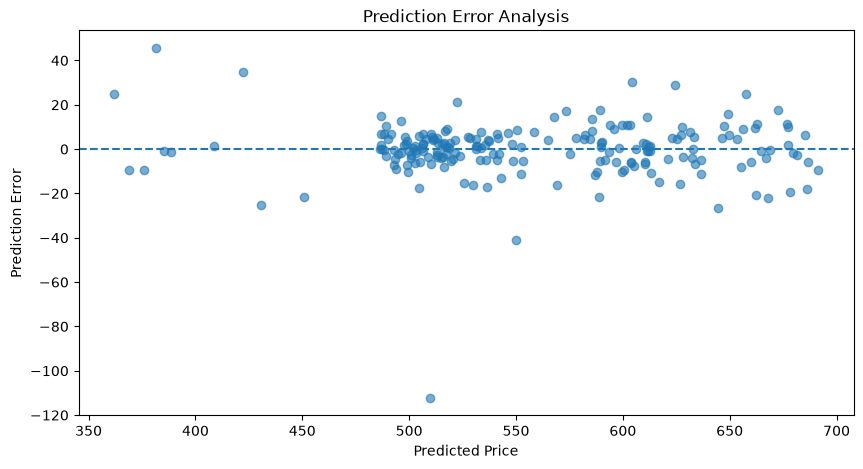

In [58]:
plt.figure(figsize=(10, 5))

plt.scatter(y_pred_best, errors, alpha=0.6)
plt.axhline(y=0, linestyle='--')

plt.title("Prediction Error Analysis")
plt.xlabel("Predicted Price")
plt.ylabel("Prediction Error")

plt.show()

## 37. Feature Importance / Coefficients

In [59]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model_improved.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients)

  Feature   Coefficient
4   Close  6.467145e-01
2     Low  2.505088e-01
1    High  2.438382e-01
0    Open -1.495659e-01
3  Volume -1.446581e-07


# Final Conclusion

In this project, historical stock market data was analyzed and machine learning models were developed to predict stock prices. The dataset was prepared by cleaning the data, selecting relevant features, splitting the data into training and testing sets, and applying Linear Regression and Random Forest models.

Several models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The Improved Linear Regression – Same Day model achieved the best overall performance, with an MAE of 3.830361, RMSE of 5.796654, and R² Score of 0.993216.

The Linear Regression – Next Day model also performed well, achieving an MAE of 7.924630, RMSE of 13.084681, and R² Score of 0.965434. However, predicting the next day's price was more challenging than predicting the same-day target.

The Random Forest model performed considerably worse, with an R² Score of 0.635275. Therefore, the Improved Linear Regression model was selected as the best-performing model for this project.

Feature coefficient analysis showed that Close had the strongest positive influence on the prediction, followed by Low and High, while Open had a negative coefficient. Volume had a very small coefficient in the fitted linear model.

Overall, the project demonstrates that Linear Regression can provide highly accurate predictions on this historical stock dataset. However, stock prices are influenced by many external factors, so the model should be considered a learning and analytical tool rather than a guarantee of future market performance.